# Variational Quantum Classifier for Binary Classification

**Authors:** Koło Naukowe Axion  
**Dataset:** Banknote Authentication (UCI ML Repository)  
**Framework:** Qiskit Machine Learning + PyTorch

## Abstract

This notebook demonstrates a hybrid Variational Quantum Circuit (VQC) for binary classification using the banknote authentication dataset. The model leverages:

- **Feature encoding**: Angle encoding via RY rotations
- **Parametrized quantum circuit (VQC)**: Hardware-efficient ansatz with ring topology entanglement
- **Measurement**: Expectation value of the Pauli-Z observable on the first qubit
- **Classical optimizer**: Adam optimizer via PyTorch's automatic differentiation

The hybrid architecture uses Qiskit's `EstimatorQNN` bridged to PyTorch via `TorchConnector`, enabling seamless gradient-based training on a simulated quantum computer.

## 1. Environment Setup

This section handles dependency installation and imports. For reproducibility, all package versions should be pinned in a production environment.

### 1.1 Package Installation (Optional)

Set `INSTALL_DEPS = True` if running in a fresh environment. For production use, pin specific versions.

In [ ]:
# Optional: Install dependencies if not already present
INSTALL_DEPS = False

if INSTALL_DEPS:
    import sys
    import subprocess
    
    packages = [
        'numpy',
        'scikit-learn',
        'ucimlrepo',
        'qiskit',
        'qiskit-machine-learning',
        'torch',
        'matplotlib'
    ]
    
    for pkg in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

### 1.2 Imports

In [ ]:
# Standard library
import random

# Third-party: Scientific computing
import numpy as np
import matplotlib.pyplot as plt

# Third-party: Machine learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from ucimlrepo import fetch_ucirepo

# Third-party: Quantum computing
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN


In [3]:
from qiskit_algorithms.gradients import ReverseEstimatorGradient

import os
from pathlib import Path
import copy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.model_selection import KFold

## 2. Reproducibility and Random Seed Control

In [4]:
def set_random_seed(seed: int = 42) -> None:
    """
    Set random seeds for reproducibility across numpy, PyTorch, and Python's random module.
    
    Parameters
    ----------
    seed : int
        Random seed value (default: 42)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Set global seed
RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)

## 3. Data Preparation

The **Banknote Authentication Dataset** contains features extracted from images of genuine and forged banknotes. We perform feature engineering (interaction term) and scale features to the range [0, π] for angle encoding.

In [5]:
def prepare_data():
    """
    Fetch and preprocess the Banknote Authentication dataset.
    Returns the full dataset without train/test split or scaling,
    which will be handled inside the cross-validation loop.
    """
    # Fetch dataset from UCI repository
    banknote_authentication = fetch_ucirepo(id=267)
    X = banknote_authentication.data.features.to_numpy()
    y = banknote_authentication.data.targets.to_numpy().ravel()
    
    # Sanity checks
    assert X.shape[1] == 4, f"Expected 4 features, got {X.shape[1]}"
    assert set(np.unique(y)) == {0, 1}, f"Expected binary labels {{0, 1}}, got {set(np.unique(y))}"
    
    # Feature engineering: interaction term
    variance = X[:, 0].reshape(-1, 1)
    skewness = X[:, 1].reshape(-1, 1)
    interaction = variance * skewness
    X_expanded = np.hstack((X, interaction))
    
    # Map labels from {0, 1} to {-1, +1} to match Z observable range
    y_mapped = 2 * y - 1
    
    # Convert to float32 for PyTorch compatibility
    return X_expanded.astype(np.float32), y_mapped.astype(np.float32)

## 4. Quantum Circuit Architecture

The quantum model consists of two components:
1. **Feature map** (angle encoding): Encodes classical data into quantum states
2. **Ansatz** (trainable circuit): Parametrized quantum circuit with learnable weights

### 4.1 Parametrized Ansatz

Ansatz with alternating rotation and entanglement layers. The circuit uses a ring topology for entanglement, alternating between forward (CRX) and reverse (CRY) connections.

In [6]:
def ansatz_Odra(n_qubits, depth):
    """
    Ansatz with Ring topology.
    Uses exclusively native-like gates: Rx, Ry, Rz, and Cz.
    No Hadamard or CX gates are used.
    """
    # For each full iteration (2 layers):
    # Layer 1: n_qubits (Ry) + n_qubits (Rz before Cz)
    # Layer 2: n_qubits (Rx) + n_qubits (Ry before Cz)
    # Total: 4 * n_qubits per iteration (depth // 2 iterations)
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('θ', params_per_iter * (depth // 2))

    qc = QuantumCircuit(n_qubits)

    for j in range(depth // 2):
        offset = j * params_per_iter

        # -------- Layer 1: Ry + Ring Cz (with Rz) --------

        # 1. Independent Ry rotations
        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)

        # 2. Ring entanglement (0-1, 1-2, ..., n-1-0)
        # Each pair: Rz on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits

            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)

        # -------- Layer 2: Rx + Ring Cz (with Ry) --------

        offset_l2 = offset + 2 * n_qubits

        # 1. Independent Rx rotations
        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)

        # 2. Reverse ring entanglement (or shifted)
        # Each pair: Ry on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits

            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)

    return qc

### 4.2 Hybrid Variational Quantum Circuit

The `HybridModel` class implements a VQC by integrating the quantum circuit with PyTorch's autograd system via Qiskit's `TorchConnector`. This enables gradient-based optimization of quantum parameters using classical optimizers.

In [7]:
class HybridModel(nn.Module):
    """
    Hybrid Variational Quantum Circuit (VQC) for binary classification.
    
    The model combines:
    1. Angle encoding feature map (classical data → quantum state)
    2. Parametrized ansatz (trainable quantum circuit)
    3. Observable measurement (quantum state → classical expectation value)
    4. PyTorch integration via TorchConnector (enables backpropagation)
    
    Parameters
    ----------
    ansatz_circuit : QuantumCircuit
        Parametrized quantum circuit with trainable weights
    num_qubits : int
        Number of qubits (must match feature dimension)
    
    Attributes
    ----------
    qnn : EstimatorQNN
        Qiskit's EstimatorQNN that computes expectation values
    quantum_layer : TorchConnector
        PyTorch-compatible wrapper enabling gradient computation
    
    Notes
    -----
    - **Feature encoding**: RY(x_i) on qubit i encodes feature x_i
    - **Observable**: Pauli-Z on qubit 0, measuring spin in computational basis
    - **Output range**: [-1, +1] (expectation value of Z operator)
    - **Gradient method**: Parameter shift rule for quantum gradients
    - **Simulator**: StatevectorEstimator (change for real quantum hardware)
    """
    
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        
        # Create angle encoding feature map
        self.feature_map = self._create_angle_encoding(num_qubits)
        
        # Compose full quantum circuit: feature_map → ansatz
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)
        
        # Separate input parameters (from feature map) and weight parameters (from ansatz)
        # This distinction is crucial for EstimatorQNN to correctly handle data vs. trainable weights
        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)
        
        # Define observable: measure Z on qubit 0 (identity on other qubits)
        # Pauli string ordering: rightmost character = qubit 0
        # Example for 5 qubits: "IIIIZ" measures Z on q0, I on q1-q4
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
        
        # Initialize statevector simulator for noiseless quantum simulation
        # NOTE: Replace with Sampler or real backend for quantum hardware deployment
        estimator = StatevectorEstimator()
        
        # Use parameter shift rule for computing quantum gradients
        # This is exact (not finite-difference) and works on hardware
        gradient = ParamShiftEstimatorGradient(estimator)
        
        # Create variational quantum circuit using EstimatorQNN
        # EstimatorQNN computes <ψ|O|ψ> where |ψ> = ansatz(weights)|feature_map(x)>
        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )
        
        # Wrap the VQC as a PyTorch module
        # TorchConnector bridges Qiskit and PyTorch autograd systems,
        # allowing standard PyTorch optimizers (SGD, Adam, etc.) to train quantum parameters
        self.quantum_layer = TorchConnector(self.qnn)
    
    def _create_angle_encoding(self, num_qubits: int) -> QuantumCircuit:
        """
        Create angle encoding feature map: |0⟩ → RY(x₀) ⊗ RY(x₁) ⊗ ... ⊗ RY(xₙ) |0⟩
        
        Each classical feature x_i ∈ [0, π] is encoded as a rotation angle on qubit i.
        This maps the feature vector to the amplitude of the quantum state.
        
        Parameters
        ----------
        num_qubits : int
            Number of qubits (and features)
        
        Returns
        -------
        QuantumCircuit
            Feature map circuit with n_qubits input parameters
        """
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the hybrid variational quantum circuit.
        
        Parameters
        ----------
        x : torch.Tensor
            Input features, shape (batch_size, num_qubits)
        
        Returns
        -------
        torch.Tensor
            Expectation values, shape (batch_size, 1), range [-1, +1]
        """
        return self.quantum_layer(x)

## 5. Training Configuration and Data Loading

In [8]:
# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.01
NUM_QUBITS = 5
ANSATZ_DEPTH = 2
K_FOLDS = 5

## 6. Model Training

We train the hybrid VQC using Mean Squared Error (MSE) loss and the Adam optimizer. The training loop evaluates both training and test performance at each epoch.

In [9]:
# Load the full dataset for cross-validation
X_full, y_full = prepare_data()

all_y_true = []
all_y_pred = []

# cross-validation training loop
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Lists to store the final and best metrics of each fold
fold_final_accuracies = []
fold_final_f1s = []
fold_best_accuracies = []
fold_best_f1s = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_full)):
    print(f"\n--- FOLD {fold + 1}/{K_FOLDS} ---")

    # Split the data into training and test sets for the current fold
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y_full[train_idx], y_full[test_idx]

    # Scale features to [-1/4π, 1/4π] for angle encoding                                        
    # Fit scaler ONLY on training data to prevent data leakage, then transform both
    scaler = MinMaxScaler(feature_range=(-np.pi/4, np.pi/4))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Ensure the directory for the fold exists to prevent FileNotFoundError
    output_root = Path('tests/shit_model')
    output_root.mkdir(parents=True, exist_ok=True)
    fold_name = f'fold_{fold+1}'
    fold_dir = output_root / fold_name
    os.makedirs(fold_dir, exist_ok=True)

    # saving data sets (using scaled data as it is fed to the model)
    train_df = pd.DataFrame(X_train_scaled)
    train_df['target'] = y_train
    test_df = pd.DataFrame(X_test_scaled)
    test_df['target'] = y_test

    train_csv = str(fold_dir / 'train_data.csv')
    test_csv = str(fold_dir / 'test_data.csv')

    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)
    print(f"Saved data sets: {train_csv}, {test_csv}")

    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

    # Create DataLoader for batched training
    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=BATCH_SIZE, shuffle=True
    )

    # Initialize a new ansatz and hybrid model for the current fold
    current_ansatz = ansatz_Odra(NUM_QUBITS, ANSATZ_DEPTH)
    model = HybridModel(current_ansatz, NUM_QUBITS)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_function = torch.nn.MSELoss()

    # Track best metrics for the current fold
    best_acc = 0.0
    best_f1 = 0.0
    best_epoch = 0
    best_model_weights = None

    # training loop
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batches_count = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()           # Reset gradients
            output = model(X_batch)         # Forward
            loss = loss_function(output, y_batch) # Loss
            loss.backward()                 # Backward
            optimizer.step()                # Update weights
    
            epoch_loss += loss.item()
            batches_count += 1
            
        # Evaluate model on the test set after each epoch to find the best model
        model.eval()
        with torch.no_grad():
            preds = (model(X_test_tensor) > 0).float() * 2 - 1
            y_true_np = y_test_tensor.numpy().flatten()
            preds_np = preds.numpy().flatten()
            
            # Calculate metrics
            current_acc = accuracy_score(y_true_np, preds_np)
            current_f1 = f1_score(y_true_np, preds_np, pos_label=1)
            
            # If current accuracy is better (or equal but better F1), save its weights
            if current_acc > best_acc or (current_acc == best_acc and current_f1 > best_f1):
                best_acc = current_acc
                best_f1 = current_f1
                best_epoch = epoch + 1
                best_model_weights = copy.deepcopy(model.state_dict())

    # Calculate final metrics using the model from the last epoch
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_tensor) > 0).float() * 2 - 1
        y_true_np = y_test_tensor.numpy().flatten()
        preds_np = preds.numpy().flatten()
        
        #Statistics for overall confusion matrix
        all_y_true.extend(y_true_np)
        all_y_pred.extend(preds_np)
        
        final_acc = accuracy_score(y_true_np, preds_np)
        final_f1 = f1_score(y_true_np, preds_np, pos_label=1)

    # Store metrics for summary
    fold_final_accuracies.append(final_acc)
    fold_final_f1s.append(final_f1)
    fold_best_accuracies.append(best_acc)
    fold_best_f1s.append(best_f1)

    # saving weights: both final and best
    final_model_path = str(fold_dir / f'model_depth_{ANSATZ_DEPTH}_final_weights.pth')
    best_model_path = str(fold_dir / f'model_depth_{ANSATZ_DEPTH}_best_weights.pth')
    
    torch.save(model.state_dict(), final_model_path)
    torch.save(best_model_weights, best_model_path)
    
    print(f"Saved weights (Final): {final_model_path}")
    print(f"Saved weights (Best):  {best_model_path}")

    # Display results for this fold
    print(f"Results fold {fold+1}:")
    print(f"  Final -> Acc: {final_acc:.4f} | F1: {final_f1:.4f}")
    print(f"  Best  -> Acc: {best_acc:.4f} | F1: {best_f1:.4f} (from epoch {best_epoch})")



--- FOLD 1/5 ---
Saved data sets: fold_1/train_data.csv, fold_1/test_data.csv
Saved weights (Final): fold_1/model_depth_2_final_weights.pth
Saved weights (Best):  fold_1/model_depth_2_best_weights.pth
Results fold 1:
  Final -> Acc: 0.8364 | F1: 0.7982
  Best  -> Acc: 0.8582 | F1: 0.8354 (from epoch 29)

--- FOLD 2/5 ---
Saved data sets: fold_2/train_data.csv, fold_2/test_data.csv
Saved weights (Final): fold_2/model_depth_2_final_weights.pth
Saved weights (Best):  fold_2/model_depth_2_best_weights.pth
Results fold 2:
  Final -> Acc: 0.9055 | F1: 0.8898
  Best  -> Acc: 0.9164 | F1: 0.9021 (from epoch 30)

--- FOLD 3/5 ---
Saved data sets: fold_3/train_data.csv, fold_3/test_data.csv
Saved weights (Final): fold_3/model_depth_2_final_weights.pth
Saved weights (Best):  fold_3/model_depth_2_best_weights.pth
Results fold 3:
  Final -> Acc: 0.8613 | F1: 0.8190
  Best  -> Acc: 0.8796 | F1: 0.8465 (from epoch 8)

--- FOLD 4/5 ---
Saved data sets: fold_4/train_data.csv, fold_4/test_data.csv
Save

## 7. Evaluation and Visualization

We evaluate the trained model using standard classification metrics and visualize the learning curves and confusion matrix.


Mean Final CV Accuracy (5 Folds): 0.8717 ± 0.0227
Mean Final CV F1 Score (5 Folds): 0.8452 ± 0.0332
--------------------------------------
Mean Best CV Accuracy (5 Folds):  0.8863 ± 0.0188
Mean Best CV F1 Score (5 Folds):  0.8663 ± 0.0235


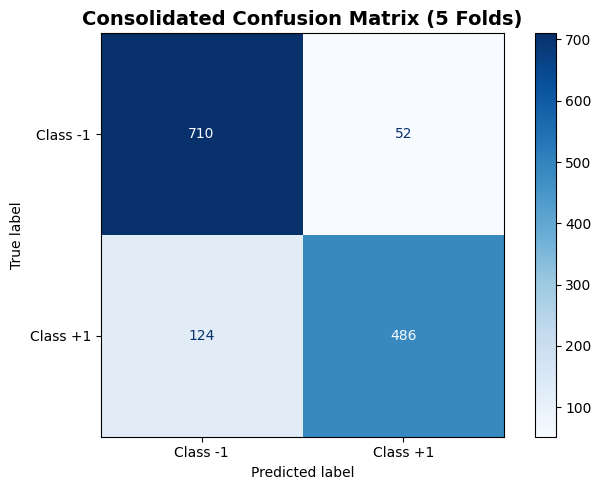

In [10]:
# Compute and display the overall average metrics and standard deviation
mean_final_acc = np.mean(fold_final_accuracies)
std_final_acc = np.std(fold_final_accuracies)
mean_final_f1 = np.mean(fold_final_f1s)
std_final_f1 = np.std(fold_final_f1s)

mean_best_acc = np.mean(fold_best_accuracies)
std_best_acc = np.std(fold_best_accuracies)
mean_best_f1 = np.mean(fold_best_f1s)
std_best_f1 = np.std(fold_best_f1s)

print(f"\n======================================")
print(f"Mean Final CV Accuracy (5 Folds): {mean_final_acc:.4f} ± {std_final_acc:.4f}")
print(f"Mean Final CV F1 Score (5 Folds): {mean_final_f1:.4f} ± {std_final_f1:.4f}")
print(f"--------------------------------------")
print(f"Mean Best CV Accuracy (5 Folds):  {mean_best_acc:.4f} ± {std_best_acc:.4f}")
print(f"Mean Best CV F1 Score (5 Folds):  {mean_best_f1:.4f} ± {std_best_f1:.4f}")
print(f"======================================")

# Compute the consolidated confusion matrix for all folds
cm_consolidated = confusion_matrix(all_y_true, all_y_pred)

# Configure and plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_consolidated, 
    display_labels=['Class -1', 'Class +1']
)

# Plot using a blue color map
cm_display.plot(ax=ax, cmap='Blues', values_format='d')

# Add title and adjust layout
ax.set_title('Consolidated Confusion Matrix (5 Folds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary and Reproducibility Notes

### Reproducibility

This notebook is designed for reproducibility:
- **Random seed**: Fixed at `RANDOM_SEED = 42` for numpy, PyTorch, and Python's random module
- **Data split**: Deterministic train/test split with `random_state=42`
- **Feature scaling**: MinMaxScaler fit only on training data, then applied to test data
- **Batch shuffling**: DataLoader uses PyTorch's random generator (seeded)

### VQC Architecture Summary

- **Qubits**: 5 (matching the 5 engineered features)
- **Ansatz depth**: 6 layers (3 macro-layers)
- **Trainable parameters**: 60 quantum parameters (2 × 5 × 6)
- **Feature encoding**: Angle encoding via RY gates
- **Observable**: Pauli-Z expectation on qubit 0
- **Optimizer**: Adam with learning rate 0.01
- **Loss function**: Mean Squared Error (MSE)

### Limitations and Future Work

1. **Simulator only**: Uses `StatevectorEstimator` for noiseless simulation. Real quantum hardware would require:
   - Replacing with a real backend (e.g., IBM Quantum)
   - Adding error mitigation strategies
   - Adjusting circuit depth for hardware constraints

2. **Feature engineering**: The interaction term (variance × skewness) was manually engineered. Automated feature selection could improve performance.

3. **Hyperparameter tuning**: Current hyperparameters (learning rate, batch size, ansatz depth) were not systematically optimized.

4. **Single-qubit measurement**: Only measuring qubit 0. Multi-qubit observables might capture more information.

### References

- Qiskit Machine Learning documentation: https://qiskit.org/ecosystem/machine-learning/
- Banknote Authentication Dataset: https://archive.ics.uci.edu/ml/datasets/banknote+authentication
- Variational Quantum Algorithms: Cerezo et al., Nature Reviews Physics 3, 625-644 (2021)
- Parameter Shift Rule: Mitarai et al., Phys. Rev. A 98, 032309 (2018)